# Toxicity All Subset Exploration

This notebook profiles a random subset of `toxicity_all.csv` so we can understand the schema, the major sources of variation, and the most useful filtering decisions before training a model.


## 1. Setup

Import the lightweight utilities we need for exploration and point the notebook to the merged toxicity dataset.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd

from src.data.dataMol import load_data, print_mol_types
from src.utils.plotting import plot_log_concentration_by_unit, plot_missing_fraction, plot_top_categories

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = Path("Data") / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading modules with transformers dependency. 

Setup complete
Data file: Data/toxicity_all.csv


## 2. Load A Random Subset

Look at a random subset instead of the first rows so the sample better reflects the diversity of the merged dataset.


In [2]:
analysis_columns = [
    "SK_unique_id",
    "data_source",
    "species_group",
    "species_group_corrected",
    "species_common_name",
    "species_latin_name",
    "chemical_name",
    "conc_unit",
    "conc",
    "conc_sign",
    "duration_unit",
    "duration",
    "effect",
    "endpoint",
    "administration_route",
    "organism_lifestage",
    "organism_habitat",
    "SMILES",
    "organism_lifestage_categorized",
    "administration_route_categorized",
    "NCBI_rank_class",
    "NCBI_rank_order",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

subset_size = 10_000
random_state = 42

df_all = load_data(DATA_PATH, analysis_columns)
subset_df = df_all.sample(n=subset_size, random_state=random_state).reset_index(drop=True)

print("Step 1: Loaded a random subset from toxicity_all.csv")
print(f"Rows in full selected dataset: {len(df_all):,}")
print(f"Rows in subset: {len(subset_df):,}")
print(f"Columns included: {len(subset_df.columns)}")
print()
print("Subset preview")
print(subset_df.head())
print()
print("Column names")
print(subset_df.columns.tolist())


Step 1: Loaded a random subset from toxicity_all.csv
Rows in full selected dataset: 561,100
Rows in subset: 10,000
Columns included: 25

Subset preview
   SK_unique_id                              data_source    species_group  \
0   AQTER562092  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt             fish   
1  AQTER1048005  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt  insects/spiders   
2    RTECS44374                             RTECS_v3.csv          rodents   
3  AQTER1242148  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt             fish   
4   AQTER728761  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt      crustaceans   

  species_group_corrected species_common_name         species_latin_name  \
0                    fish      Fathead Minnow        pimephales promelas   
1                 insects       Hornfaced Bee           osmia cornifrons   
2                 rodents               mouse               Mus musculus   
3                    fish  California Halibut  paralichthys californicus   
4    

## 3. Check The Layout And Missingness

Before filtering anything, check which columns are dense, which ones are sparse, and how much information is available for core modeling fields.


Step 2: Column-level overview for the subset
                                    dtype  non_null  missing_frac  n_unique
organism_lifestage_categorized     object      2836         0.716         3
organism_lifestage                 object      3491         0.651        91
administration_route_categorized   object      6534         0.347        22
organism_habitat                   object      6604         0.340         3
duration                          float64      7627         0.237       422
duration_unit                      object      7640         0.236        25
administration_route               object      8881         0.112       106
chemical_name                      object      9112         0.089      3897
NCBI_rank_species                 float64      9195         0.080      1523
NCBI_rank_genus                   float64      9622         0.038      1252
NCBI_rank_class                   float64      9794         0.021        78
species_group                      object  

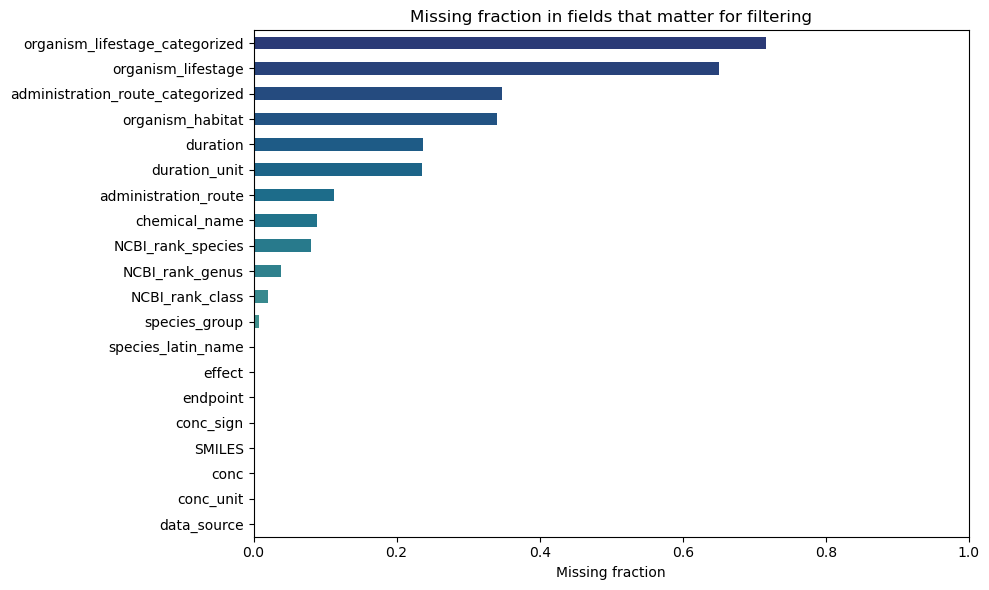

In [3]:
summary_columns = [
    "data_source",
    "species_group",
    "species_latin_name",
    "chemical_name",
    "SMILES",
    "conc",
    "conc_unit",
    "conc_sign",
    "duration",
    "duration_unit",
    "effect",
    "endpoint",
    "administration_route",
    "organism_lifestage",
    "organism_habitat",
    "organism_lifestage_categorized",
    "administration_route_categorized",
    "NCBI_rank_class",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

column_summary = pd.DataFrame({
    "dtype": subset_df[summary_columns].dtypes.astype(str),
    "non_null": subset_df[summary_columns].notna().sum(),
    "missing_frac": subset_df[summary_columns].isna().mean().round(3),
    "n_unique": subset_df[summary_columns].nunique(dropna=True),
}).sort_values(["missing_frac", "n_unique"], ascending=[False, False])

print("Step 2: Column-level overview for the subset")
print(column_summary.to_string())

plot_missing_fraction(
    subset_df,
    columns=summary_columns,
    title="Missing fraction in fields that matter for filtering",
    figsize=(10, 6),
)


## 4. Organism And Taxonomy Variety

Look at how broad the subset is across species groups, Latin names, and NCBI taxonomy ids.


Step 3: Taxonomy coverage
                 column  unique_non_null  missing_frac
          species_group               16         0.007
species_group_corrected               20         0.000
     species_latin_name             2025         0.002
        NCBI_rank_class               78         0.021
        NCBI_rank_order              267         0.035
       NCBI_rank_family              652         0.032
        NCBI_rank_genus             1252         0.038
      NCBI_rank_species             1523         0.080

Top species groups
species_group
rodents                          2731
fish                             1692
flowers, trees, shrubs, ferns    1195
insects/spiders                  1184
crustaceans                      1121
algae                             618
worms                             277
molluscs                          208
invertebrates                     204
amphibians                        201
fungi                             199
birds                      

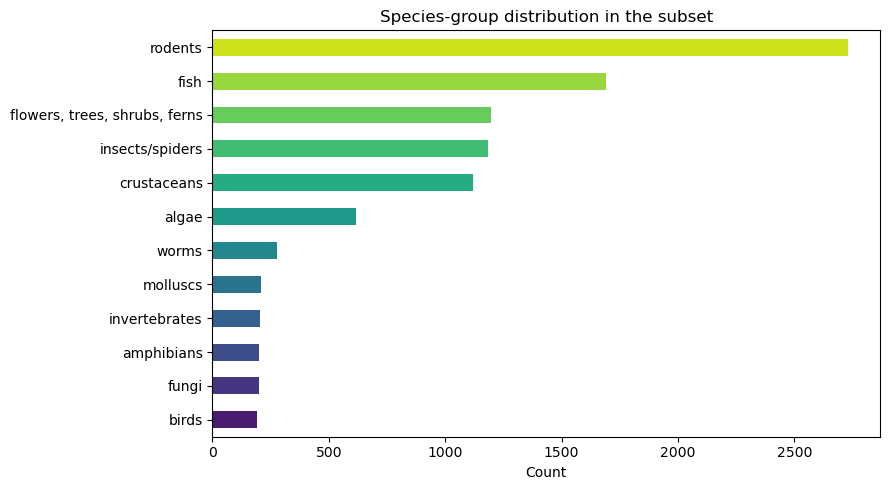

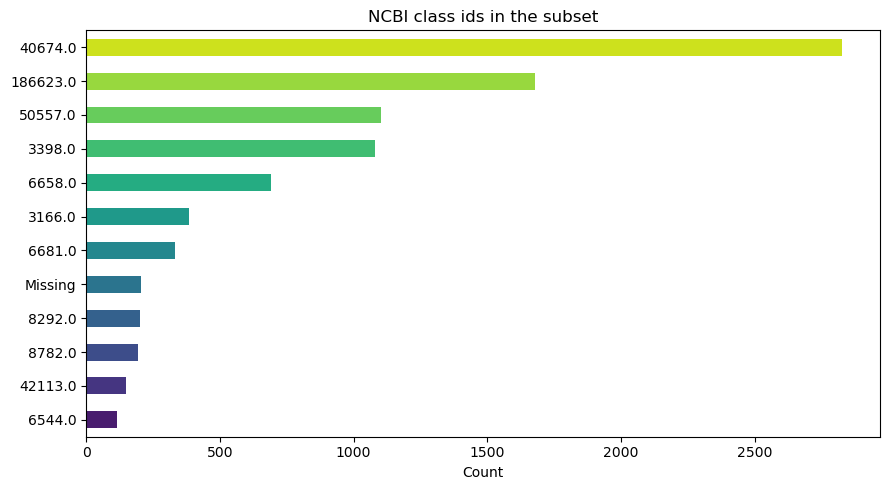

In [4]:
taxonomy_levels = [
    "species_group",
    "species_group_corrected",
    "species_latin_name",
    "NCBI_rank_class",
    "NCBI_rank_order",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

taxonomy_summary = pd.DataFrame({
    "column": taxonomy_levels,
    "unique_non_null": [subset_df[col].nunique(dropna=True) for col in taxonomy_levels],
    "missing_frac": [subset_df[col].isna().mean().round(3) for col in taxonomy_levels],
})

print("Step 3: Taxonomy coverage")
print(taxonomy_summary.to_string(index=False))
print()
print("Top species groups")
print(subset_df["species_group"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top Latin names")
print(subset_df["species_latin_name"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top NCBI class ids")
print(subset_df["NCBI_rank_class"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top NCBI species ids")
print(subset_df["NCBI_rank_species"].fillna("Missing").value_counts().head(12).to_string())

plot_top_categories(subset_df["species_group"], "Species-group distribution in the subset", top_n=12, figsize=(9, 5))
plot_top_categories(subset_df["NCBI_rank_class"], "NCBI class ids in the subset", top_n=12, figsize=(9, 5))


## 5. Molecule Variety

Check how many unique molecules appear in the subset, how often they repeat, and whether there are salts, lone atoms, or metals to think about.


In [5]:
smiles_counts = subset_df["SMILES"].dropna().value_counts()
unique_smiles = subset_df["SMILES"].nunique(dropna=True)
unique_chemical_names = subset_df["chemical_name"].nunique(dropna=True)

print("Step 4: Molecule diversity")
print(f"Rows in subset: {len(subset_df):,}")
print(f"Unique SMILES: {unique_smiles:,}")
print(f"Unique chemical names: {unique_chemical_names:,}")
print(f"Duplicate rows by SMILES: {len(subset_df) - unique_smiles:,}")
print(f"Median records per SMILES: {smiles_counts.median():.1f}")
print(f"95th percentile records per SMILES: {smiles_counts.quantile(0.95):.1f}")
print(f"Max records for a single SMILES: {smiles_counts.max():.0f}")
print()
print_mol_types(subset_df.dropna(subset=["SMILES"]))
print()

top_molecules = (
    subset_df.groupby(["SMILES", "chemical_name"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(12)
    .reset_index(name="n_records")
)
top_molecules["SMILES_short"] = top_molecules["SMILES"].fillna("Missing").str.slice(0, 70)

print("Most repeated molecules in the subset")
print(top_molecules[["n_records", "chemical_name", "SMILES_short"]].to_string(index=False))


Step 4: Molecule diversity
Rows in subset: 10,000
Unique SMILES: 4,144
Unique chemical names: 3,897
Duplicate rows by SMILES: 5,856
Median records per SMILES: 1.0
95th percentile records per SMILES: 7.8
Max records for a single SMILES: 190



[19:41:04] WARNING: not removing hydrogen atom without neighbors
[19:41:04] WARNING: not removing hydrogen atom without neighbors
[19:41:04] WARNING: not removing hydrogen atom without neighbors


Total molecules: 10000
Unique molecules: 4144
Salts: 2408, 24.08%
Single atoms: 29, 0.29%
Metals: 1827, 18.27%

Most repeated molecules in the subset
 n_records                                                                                                                              chemical_name                                              SMILES_short
       180                                                                                                        Sulfuric acid copper(2+) salt (1:1)                                  O=S(=O)([O-])[O-].[Cu+2]
       118                                                                             6-Chloro-N-ethyl-N'-(1-methylethyl)-1,3,5-triazine-2,4-diamine                                   CCNc1nc(Cl)nc(NC(C)C)n1
       116                                                                    Phosphorothioic acid, O,O-Diethyl O-(3,5,6-trichloro-2-pyridinyl) ester                          CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl
        85        

[19:41:04] WARNING: not removing hydrogen atom without neighbors
[19:41:04] WARNING: not removing hydrogen atom without neighbors
[19:41:04] WARNING: not removing hydrogen atom without neighbors


## 6. Experimental Setup Variety

Inspect the main experiment descriptors that are likely to drive filtering decisions: data source, effect, endpoint, administration route, concentration unit, and duration unit.


Step 5: Experimental setup fields

Top data sources
data_source
2025-06-24_Merged_REACH_ECOTOX_EFSA.txt    7492
RTECS_v3.csv                               2125
Acute_Toxicity_cleaned_v1.txt               264
Reproductive_toxicity_cleaned_v1.txt         85
Carcinogenicity_cleaned_v1.txt               34

Top effects
effect
MOR    4942
POP    1611
GRO     961
BEH     695
REP     526
ITX     324
DVP     290
PHY     259
MPH     208
INJ     127
CAR      57

Top endpoints
endpoint
EC50    5616
NOEC    2394
LOEC    1714
EC10     276

Top administration routes
administration_route
S                  1902
Missing            1119
R                   800
Intraperitoneal     747
Oral                569
EN                  523
F                   476
Intravenous         458
SP                  415
FD                  333
HS                  313
DA                  270
Subcutaneous        165
oral: gavage        148
GV                  138

Top concentration units
conc_unit
mg/L          4616
mg/kg 

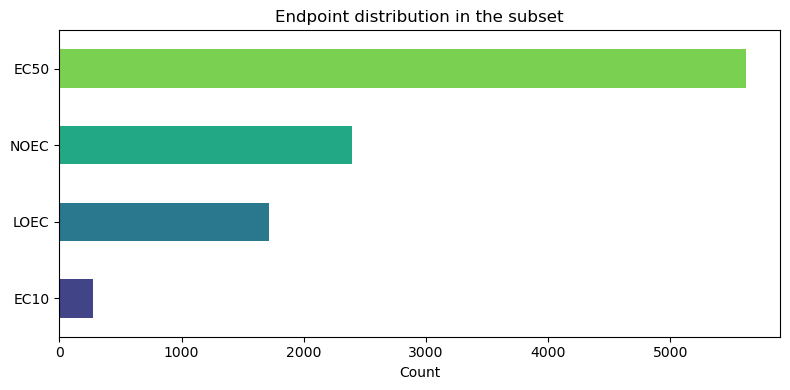

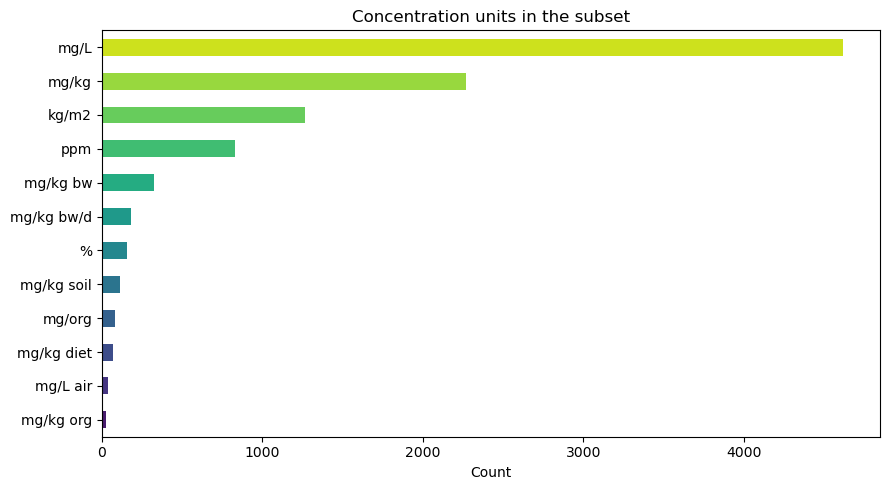

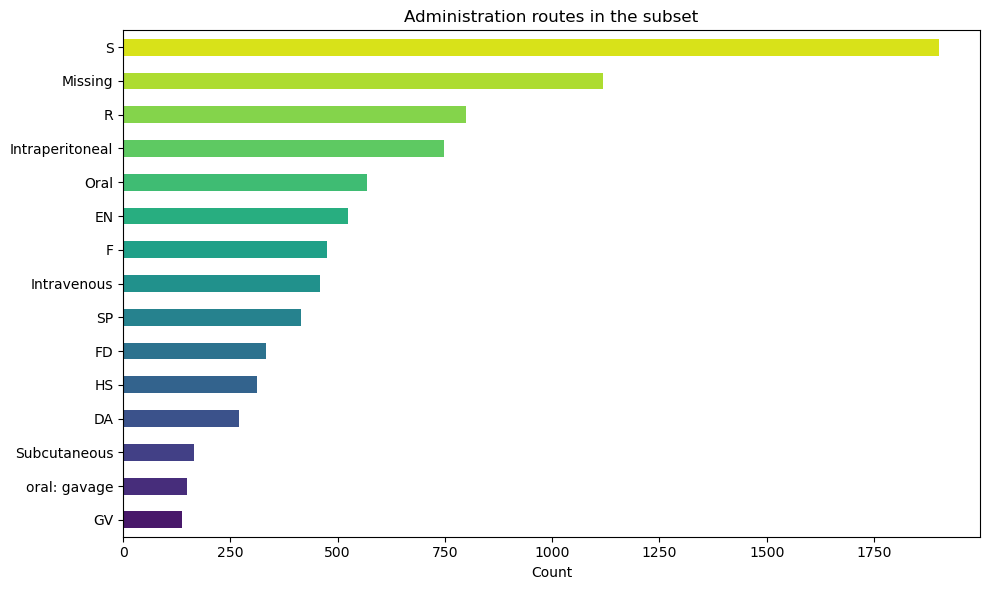

In [6]:
print("Step 5: Experimental setup fields")
print()
print("Top data sources")
print(subset_df["data_source"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top effects")
print(subset_df["effect"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top endpoints")
print(subset_df["endpoint"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top administration routes")
print(subset_df["administration_route"].fillna("Missing").value_counts().head(15).to_string())
print()
print("Top concentration units")
print(subset_df["conc_unit"].fillna("Missing").value_counts().head(15).to_string())
print()
print("Top duration units")
print(subset_df["duration_unit"].fillna("Missing").value_counts().head(15).to_string())
print()
print("Concentration sign values")
print(subset_df["conc_sign"].fillna("Missing").value_counts().to_string())

plot_top_categories(subset_df["endpoint"], "Endpoint distribution in the subset", top_n=10, figsize=(8, 4))
plot_top_categories(subset_df["conc_unit"], "Concentration units in the subset", top_n=12, figsize=(9, 5))
plot_top_categories(subset_df["administration_route"], "Administration routes in the subset", top_n=15, figsize=(10, 6))


## 7. Concentration Scales And Common Combinations

Different endpoints and units live on very different scales, so it helps to inspect both the numeric spread and the most common endpoint-unit combinations.


Step 6: Concentration scale by unit
            n_records  min_value  median_value  p95_value  max_value
conc_unit                                                           
mg/L             4616     0.0000        1.4000  1000.0000  1200000.0
mg/kg            2270     0.0050      180.0000  2500.0000   150000.0
kg/m2            1268     0.0000        0.0001     0.0045        0.2
ppm               830     0.0000       13.2500  5000.0000   539600.0
mg/kg bw          324     0.0700      612.0000  7460.0000    23000.0
mg/kg bw/d        184     0.0500      100.0000  2712.5000    11298.0
%                 155     0.0001        0.3000    21.5000       98.0
mg/kg soil        115     0.0002       40.2000  1350.8150    50000.0
mg/org             79     0.0000        0.0002     0.1675        7.5
mg/kg diet         71     0.0050       33.0000  6250.0000    40175.0
mg/L air           38     0.0003        0.6045    55.8215       87.0
mg/kg org          23     1.6000      500.0000  2240.0000     4640.

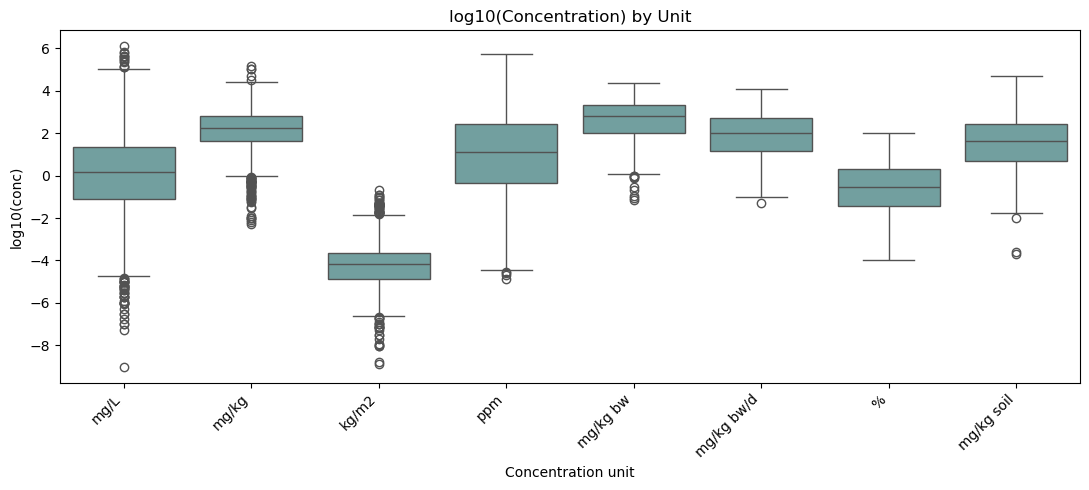

In [7]:
unit_stats = (
    subset_df.groupby("conc_unit")["conc"]
    .agg(
        n_records="size",
        min_value="min",
        median_value="median",
        p95_value=lambda s: s.quantile(0.95),
        max_value="max",
    )
    .sort_values("n_records", ascending=False)
    .head(12)
    .round(4)
)

print("Step 6: Concentration scale by unit")
print(unit_stats.to_string())
print()
print("Most common endpoint x concentration-unit combinations")
print(
    subset_df.groupby(["endpoint", "conc_unit"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)
print()
print("Most common species-group x endpoint x unit combinations")
print(
    subset_df.groupby(["species_group", "endpoint", "conc_unit"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

plot_log_concentration_by_unit(subset_df, top_n=8, figsize=(11, 5))


## 8. Filtering Clues For Modeling

Use the subset to estimate which kinds of filters are realistic before moving on to feature engineering or model training.


In [8]:
core_model_fields = ["SMILES", "conc", "conc_unit", "endpoint", "effect", "NCBI_rank_species"]

filter_readiness = pd.Series({
    "Rows with all core model fields": subset_df[core_model_fields].notna().all(axis=1).sum(),
    "Rows with duration and unit present": subset_df[["duration", "duration_unit"]].notna().all(axis=1).sum(),
    "Rows with administration route present": subset_df["administration_route"].notna().sum(),
    "Rows with categorized route present": subset_df["administration_route_categorized"].notna().sum(),
    "Rows with categorized lifestage present": subset_df["organism_lifestage_categorized"].notna().sum(),
})

is_aquatic_group = subset_df["species_group"].isin(["fish", "crustaceans", "algae", "amphibians", "molluscs", "worms", "invertebrates"])
is_mammalian_group = subset_df["species_group"].isin(["rodents", "mammals", "primates", "birds"])
mgkg_like = subset_df["conc_unit"].astype(str).str.contains("mg/kg", na=False)

candidate_filters = pd.DataFrame([
    {
        "candidate_subset": "Aquatic acute-like (mg/L + EC50)",
        "rows_in_subset": ((subset_df["conc_unit"] == "mg/L") & (subset_df["endpoint"] == "EC50") & is_aquatic_group).sum(),
    },
    {
        "candidate_subset": "Aquatic chronic-like (mg/L + NOEC/LOEC/EC10)",
        "rows_in_subset": ((subset_df["conc_unit"] == "mg/L") & subset_df["endpoint"].isin(["NOEC", "LOEC", "EC10"]) & is_aquatic_group).sum(),
    },
    {
        "candidate_subset": "Mammalian acute-like (mg/kg family + EC50)",
        "rows_in_subset": (mgkg_like & (subset_df["endpoint"] == "EC50") & is_mammalian_group).sum(),
    },
    {
        "candidate_subset": "Rows with duration available",
        "rows_in_subset": subset_df[["duration", "duration_unit"]].notna().all(axis=1).sum(),
    },
])

print("Step 7: How filter-ready is this subset?")
print(filter_readiness.to_string())
print()
print("Candidate subsets to inspect next")
print(candidate_filters.to_string(index=False))


Step 7: How filter-ready is this subset?
Rows with all core model fields            9195
Rows with duration and unit present        7627
Rows with administration route present     8881
Rows with categorized route present        6534
Rows with categorized lifestage present    2836

Candidate subsets to inspect next
                            candidate_subset  rows_in_subset
            Aquatic acute-like (mg/L + EC50)            2207
Aquatic chronic-like (mg/L + NOEC/LOEC/EC10)            1404
  Mammalian acute-like (mg/kg family + EC50)            2279
                Rows with duration available            7627


## 9. What Stands Out From This Sample

- The file mixes very different regimes, including aquatic ecotoxicology and mammalian acute toxicity.
- Units are not harmonized, so filtering by `conc_unit` is likely a first-step decision rather than something to postpone.
- Endpoints are dominated by `EC50`, but `NOEC`, `LOEC`, and `EC10` are also common enough to matter.
- Route, duration, and lifestage are much less complete than the core response columns, so requiring them will shrink the usable data.
- Taxonomy coverage is broad enough that filtering by species group or taxonomic rank should be feasible, but the exact choice will strongly affect class balance and unit consistency.
